In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/MachineLearning/Praktikum7"

In [ ]:
import pandas as pd
df = pd.read_csv(path + '/Data/college.csv')
df.head()

,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID      8000 non-null   int64 
 1   Gender         8000 non-null   object
 2   Parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   Encourage      8000 non-null   object
 5   Plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


In [ ]:
#Cek missing value
df.isnull().sum()

,0
StudentID,0
Gender,0
Parent_income,0
IQ,0
Encourage,0
Plan,0


In [ ]:
# Cek duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

In [ ]:
# Cek duplicate ulang setelah menghapus
df.duplicated().sum()

np.int64(0)

In [ ]:
# Menghapus kolom ID dikarenakan kurang relevan
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

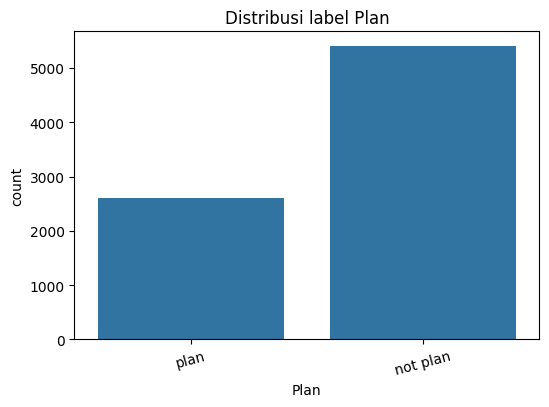

In [ ]:
plt.figure(figsize = (6, 4) )
sns.countplot(x = 'Plan', data=df)
plt.title('Distribusi label Plan')
plt.xticks (rotation=15)
plt.show()

In [ ]:
# mapping label -> kode untuk target
plan_cat = df['Plan'].astype('category')
plan_classes = list(plan_cat.cat.categories)   # urutan kelas
df['Plan'] = plan_cat.cat.codes                    # y numerik

# fitur kategorikal lain (Gender, Encourage) → kode juga
for col in ['Gender', 'Encourage']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes
df.head()

,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,1,53900,118,0,1
1,4561,0,24900,87,1,0
2,4563,0,65800,93,1,0
3,4565,1,11440,117,0,1
4,4567,0,16700,102,1,0


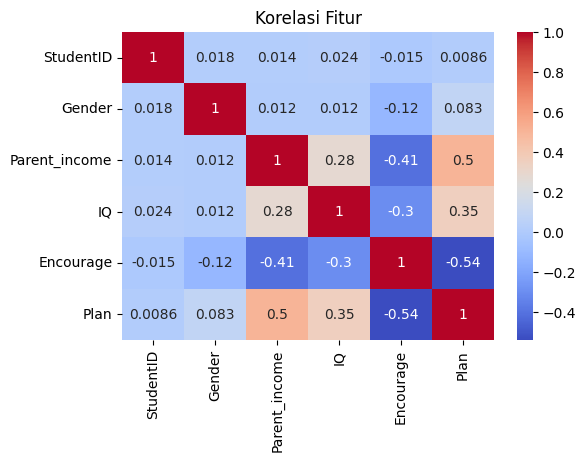

In [ ]:
# Korelasi
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

In [ ]:
# Memilih fitur dan target
feature_cols = ['Gender', 'Parent_income', 'IQ', 'Encourage']
X = df [feature_cols]
y = df['Plan']

In [ ]:
#Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
len(X_train), len(X_test)

(6400, 1600)

In [ ]:
# Membangun model
model = DecisionTreeClassifier(random_state=42, max_depth=3, criterion='gini')
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
print("Akurasi:", round(accuracy_score(y_test, y_pred) *100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=plan_classes
))

Akurasi: 81.88 %

Confusion Matrix:
 [[982  99]
 [191 328]]

Classification Report:
               precision    recall  f1-score   support

    not plan       0.84      0.91      0.87      1081
        plan       0.77      0.63      0.69       519

    accuracy                           0.82      1600
   macro avg       0.80      0.77      0.78      1600
weighted avg       0.81      0.82      0.81      1600



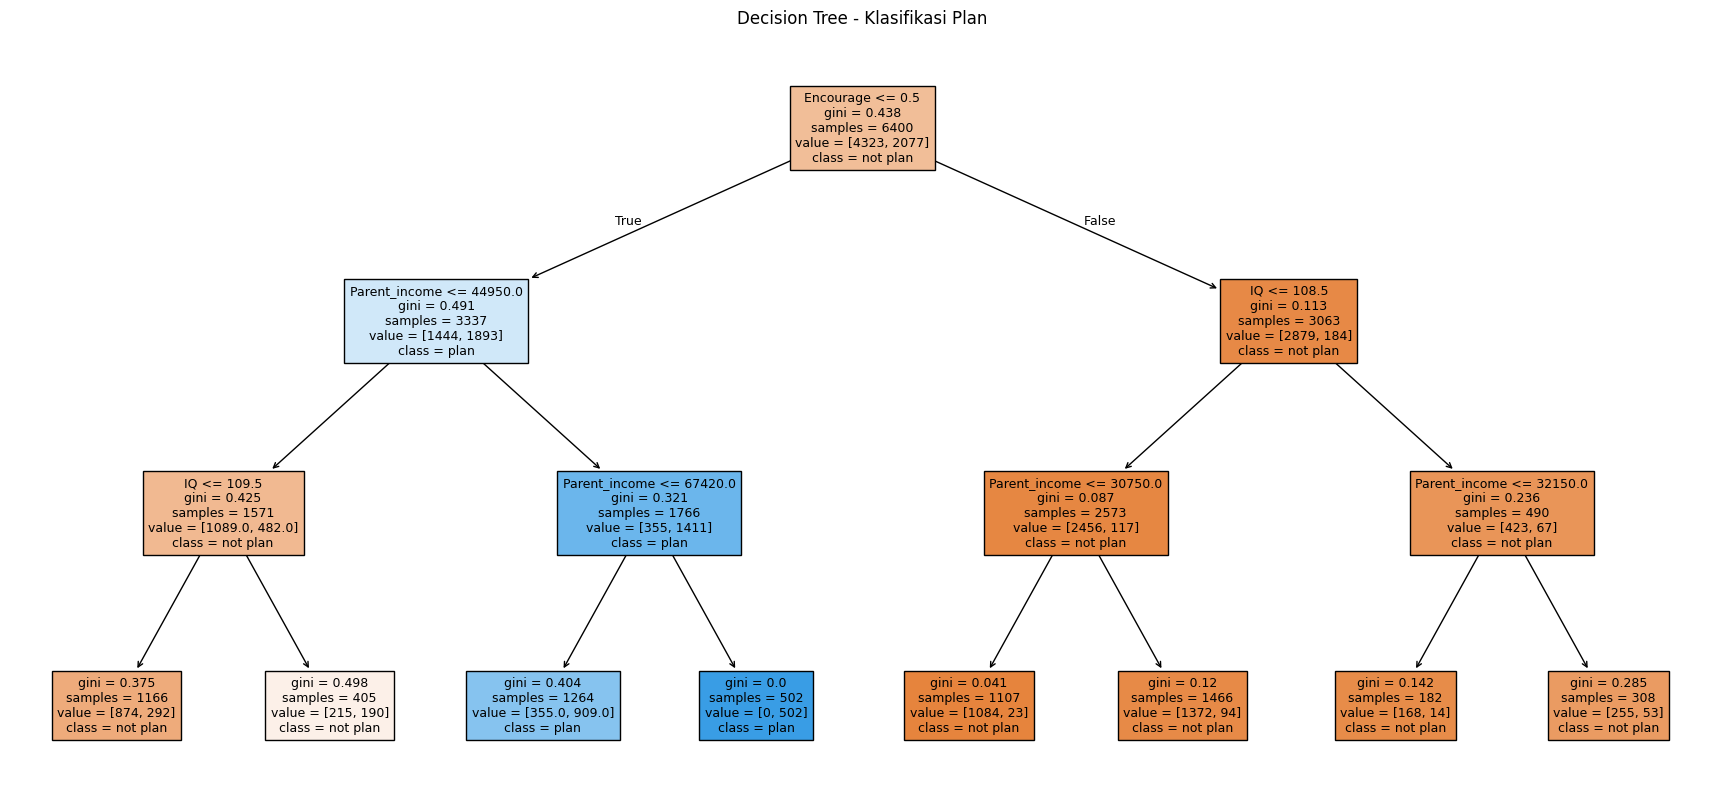

In [ ]:
# Visualisasi model
plt.figure(figsize=(22,10))
plot_tree(
    model,
    feature_names=feature_cols,
    class_names=plan_classes,        # kembali ke nama kelas asli
    filled=True,
    fontsize=9
)
plt.title("Decision Tree - Klasifikasi Plan")
plt.show()

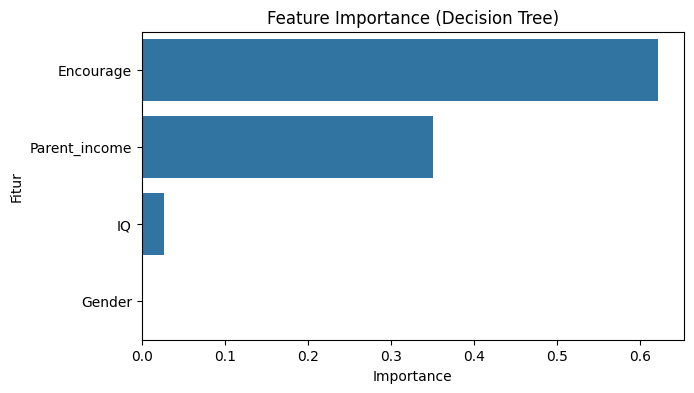

,0
Encourage,0.621928
Parent_income,0.351117
IQ,0.026954
Gender,0.000000


In [ ]:
#Fitur yang penting

imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(x=imp, y=imp.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

imp

In [ ]:
scores = {}
for d in range(2, nine:= 9):
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    scores [d] = accuracy_score(y_test, m.predict(X_test))

scores
best_d = max(scores, key=scores.get)
print("Best max_depth:", best_d, "| Acc:", round(scores[best_d]*100,2), "%")

Best max_depth: 4 | Acc: 82.62 %
